<a href="https://colab.research.google.com/github/OJB-Quantum/Generative-Layout-Notebooks/blob/main/Fibonacci_Word_Fractal_Resonators_PHIDL_GDSTK_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

Nearest-neighbor centerline pitch check: pitch=57.200 µm, outer CPW width=22.000 µm, edge-to-edge=35.200 µm
Generated true Fibonacci-word fractal CPW resonator
GDS path: /content/fibonacci_cpw_outputs/true_fibonacci_word_9_iteration_cpw_resonator.gds
Fibonacci substitutions: 9
Turn index base: 0
Fibonacci word length: 89 segments
Raw centerline points: 90
Cleaned centerline points: 57
Smoothed centerline points: 19747
Segment length: 57.200 µm
Euler bend radius: 12.000 µm
Raw centerline length: 5.0908 mm
Smoothed centerline length: 4.6957 mm
Estimated quarter-wave resonance: 6.4101 GHz
Chip envelope: 2.200 mm × 2.200 mm
Ground layer: 1
Gap layer: 2
Center conductor layer: 3


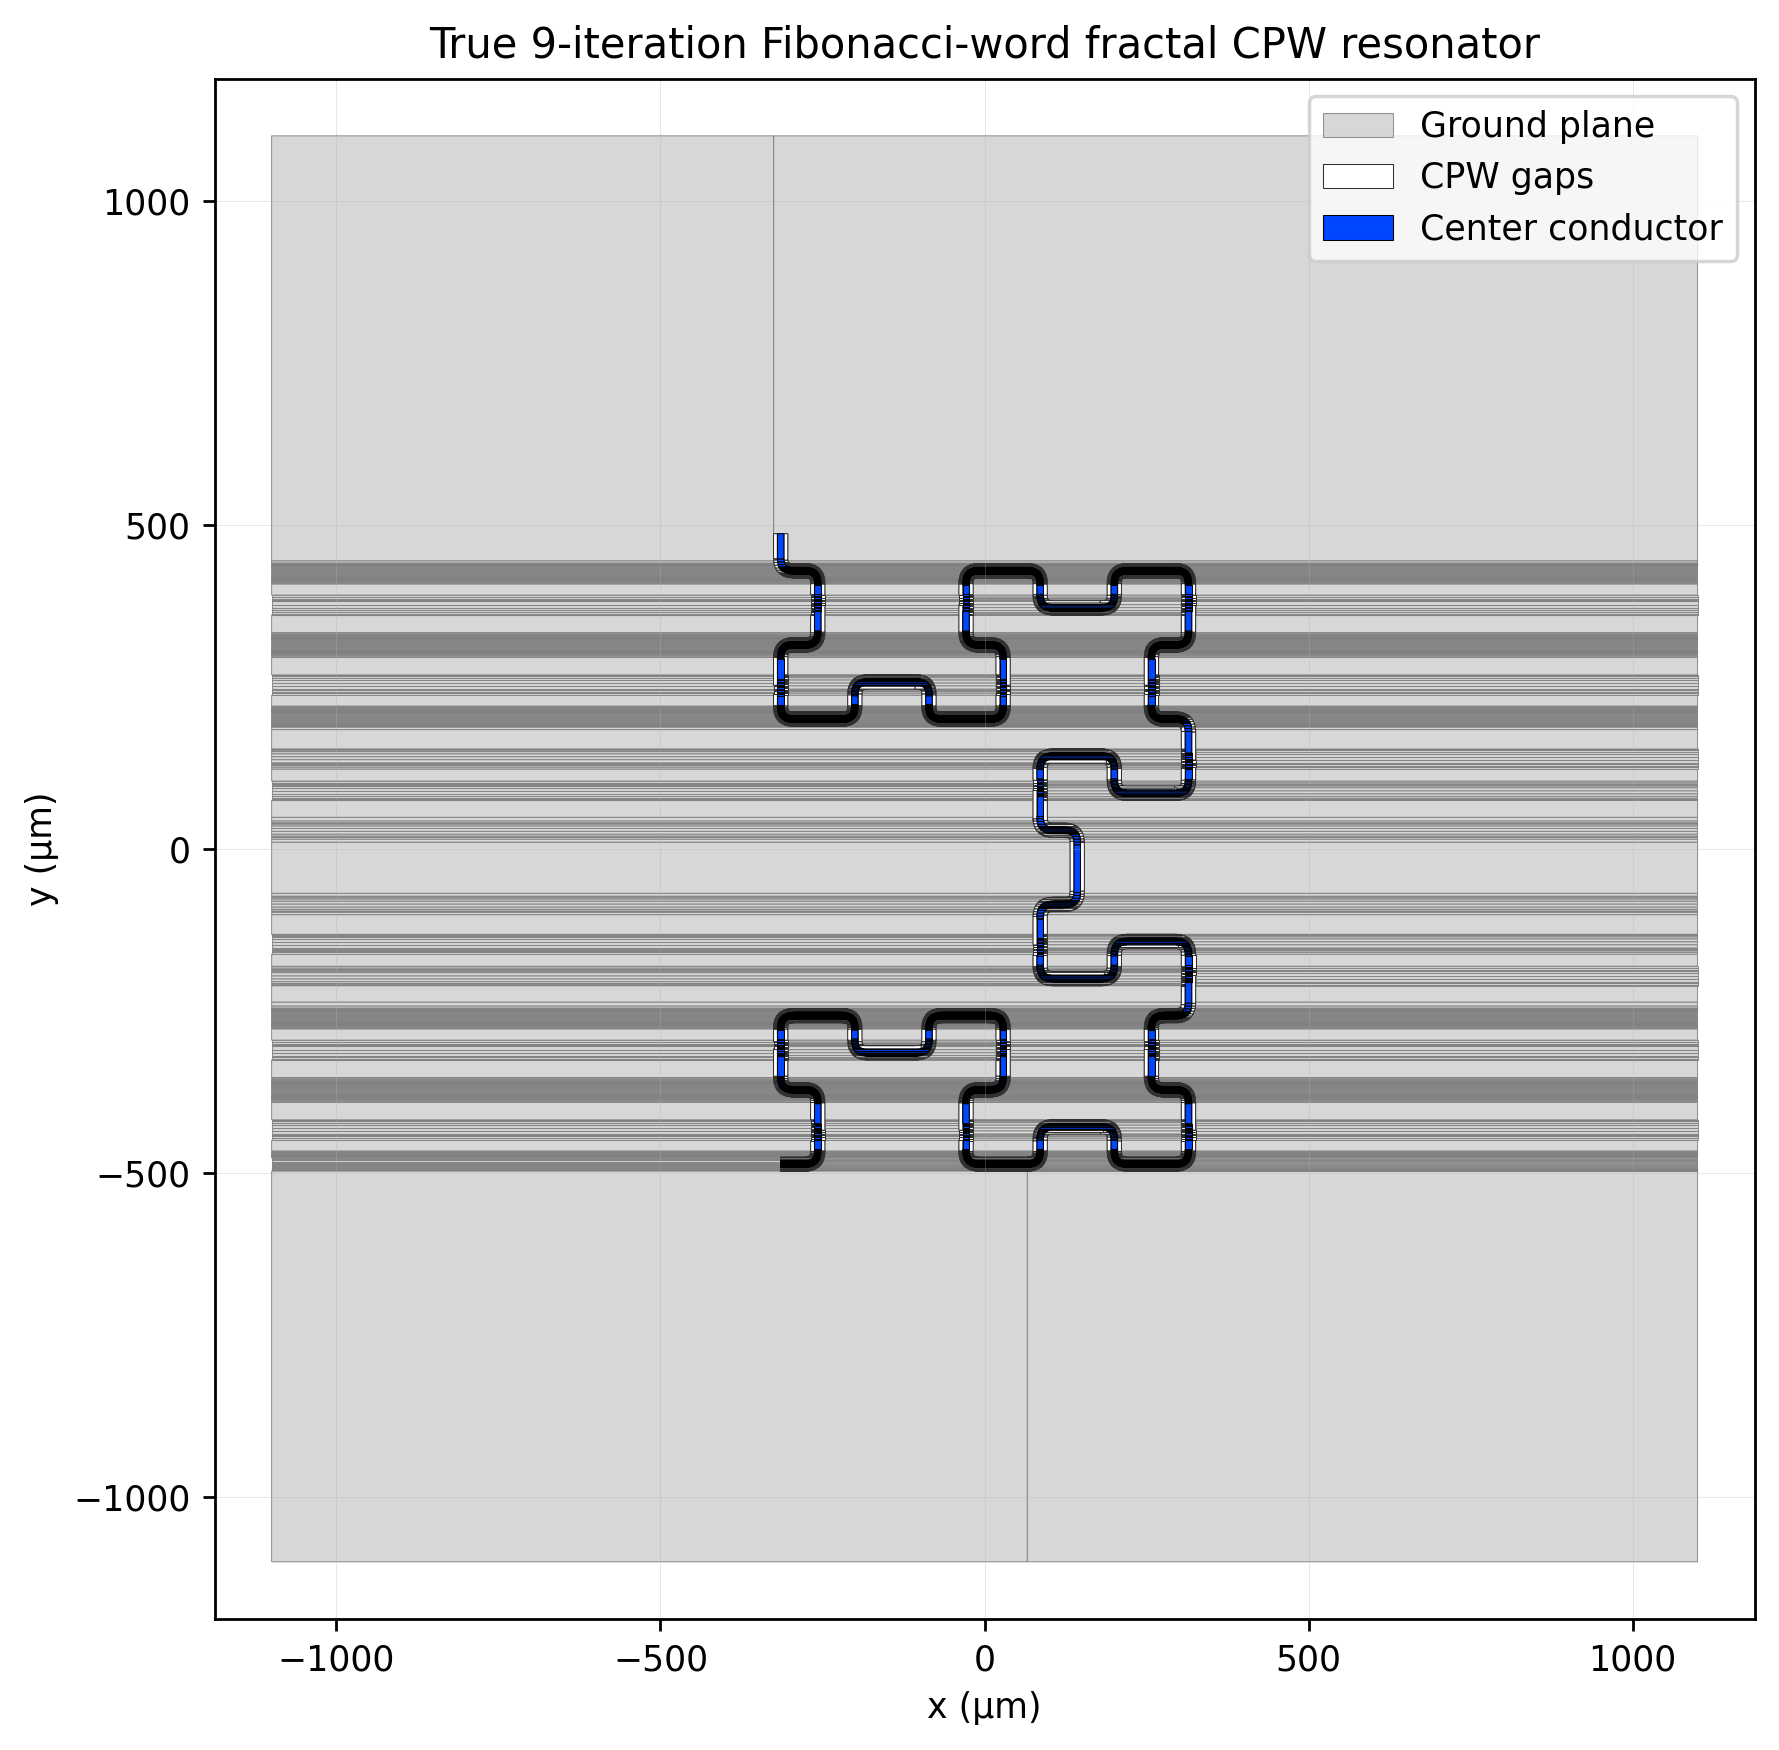

In [1]:
#@title Generate a true 9-iteration Fibonacci-word fractal CPW resonator with PHIDL + GDSTK
"""Generate a 9-iteration Fibonacci-word fractal CPW resonator GDS.

The script uses the Fibonacci-word odd-even drawing rule to generate the
centerline, PHIDL to smooth the orthogonal centerline with Euler bends, and
GDSTK to construct the ground plane, CPW gaps, center conductor, GDS export,
and Matplotlib preview.

Generated regions:
    1. Ground plane metal.
    2. CPW gap openings.
    3. CPW center conductor.
"""

from __future__ import annotations

import importlib.util
import math
import subprocess
import sys
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable

# =============================================================================
# Installation control knobs
# =============================================================================
INSTALL_MISSING_PACKAGES = True
PACKAGE_NAMES = ("phidl", "gdstk", "numpy", "matplotlib")

# =============================================================================
# Fibonacci-word curve control knobs
# =============================================================================
FIBONACCI_ITERATIONS = 9
TURN_INDEX_BASE = 0
START_HEADING_DEG = 0
ZERO_ON_EVEN_TURNS_LEFT = True

# =============================================================================
# Resonator geometry control knobs
# =============================================================================
TARGET_RESONANCE_GHZ = 6.0
EFFECTIVE_EPSILON = 6.2
USE_TARGET_QUARTER_WAVE_LENGTH = True

CENTER_WIDTH_UM = 10.0
GAP_WIDTH_UM = 6.0
MIN_SEGMENT_LENGTH_UM = 42.0
BEND_RADIUS_UM = 12.0
PATH_TOLERANCE_UM = 0.02

CHIP_MARGIN_UM = 350.0
MIN_CHIP_SIZE_UM = 2200.0

# =============================================================================
# GDS output control knobs
# =============================================================================
OUTPUT_DIR = Path("/content/fibonacci_cpw_outputs")
GDS_PATH = OUTPUT_DIR / "true_fibonacci_word_9_iteration_cpw_resonator.gds"

GDS_UNIT_M = 1.0e-6
GDS_PRECISION_M = 1.0e-9
BOOLEAN_PRECISION_UM = 1.0e-3
MAX_POLYGON_POINTS = 199

GROUND_LAYER = 1
GROUND_DATATYPE = 0
GAP_LAYER = 2
GAP_DATATYPE = 0
CENTER_LAYER = 3
CENTER_DATATYPE = 0
TEXT_LAYER = 10
TEXT_DATATYPE = 0

ADD_TEXT_LABEL = True
TEXT_SIZE_UM = 45.0

# =============================================================================
# Preview control knobs
# =============================================================================
MPL_DPI = 250
SHOW_PREVIEW = True
PREVIEW_LINEWIDTH = 0.30
SHOW_CENTERLINE_OVERLAY = False


def ensure_packages() -> None:
    """Install missing packages with uv pip when requested."""
    if INSTALL_MISSING_PACKAGES is False:
        return

    missing = [
        package for package in PACKAGE_NAMES
        if importlib.util.find_spec(package) is None
    ]

    if len(missing) == 0:
        return

    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "uv"],
        check=True,
    )
    subprocess.run(
        [
            sys.executable,
            "-m",
            "uv",
            "pip",
            "install",
            "--system",
            "-q",
            *missing,
        ],
        check=True,
    )


ensure_packages()

import gdstk
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import phidl.path as pp
from matplotlib.patches import Polygon as MplPolygon


mpl.rcParams["figure.dpi"] = MPL_DPI
mpl.rcParams["savefig.dpi"] = MPL_DPI


@dataclass(frozen=True)
class CpwSummary:
    """Container for resonator geometry summary values."""

    word_length: int
    raw_length_um: float
    smoothed_length_um: float
    estimated_f0_ghz: float
    chip_width_um: float
    chip_height_um: float
    segment_length_um: float
    bend_radius_um: float
    point_count_raw: int
    point_count_cleaned: int
    point_count_smoothed: int


def build_fibonacci_word(iterations: int) -> str:
    """Build a Fibonacci word using substitutions 0 -> 01 and 1 -> 0."""
    word = "0"
    for _ in range(iterations):
        word = "".join("01" if symbol == "0" else "0" for symbol in word)
    return word


def target_quarter_wave_length_um(
    frequency_ghz: float,
    effective_epsilon: float,
) -> float:
    """Return the approximate CPW quarter-wave resonator length in micrometers."""
    speed_of_light_um_per_s = 299_792_458.0 * 1.0e6
    frequency_hz = frequency_ghz * 1.0e9
    phase_velocity_um_per_s = speed_of_light_um_per_s / math.sqrt(
        effective_epsilon
    )
    return phase_velocity_um_per_s / (4.0 * frequency_hz)


def choose_segment_length_um(word_length: int) -> float:
    """Choose a segment length from target frequency and spacing constraints."""
    outer_width_um = CENTER_WIDTH_UM + 2.0 * GAP_WIDTH_UM
    pitch_floor_um = max(MIN_SEGMENT_LENGTH_UM, 2.6 * outer_width_um)

    if USE_TARGET_QUARTER_WAVE_LENGTH:
        target_length_um = target_quarter_wave_length_um(
            TARGET_RESONANCE_GHZ,
            EFFECTIVE_EPSILON,
        )
        segment_length_um = target_length_um / float(word_length)
        return max(segment_length_um, pitch_floor_um)

    return pitch_floor_um


def turn_direction_for_zero(symbol_index: int) -> int:
    """Return the 90-degree turn sign for a zero symbol at a word position."""
    parity_index = symbol_index + TURN_INDEX_BASE
    even_position = parity_index % 2 == 0

    if even_position == ZERO_ON_EVEN_TURNS_LEFT:
        return 1

    return -1


def build_fibonacci_turtle_points(
    word: str,
    segment_length_um: float,
) -> np.ndarray:
    """Convert a Fibonacci word into the odd-even Fibonacci fractal centerline.

    Every symbol draws one forward segment. A one keeps the current heading. A
    zero turns after the forward segment, with the turn set by the parity of the
    symbol position in the word.
    """
    heading_deg = START_HEADING_DEG
    x_um = 0.0
    y_um = 0.0
    points = [(x_um, y_um)]

    direction_by_heading = {
        0: np.array([1.0, 0.0]),
        90: np.array([0.0, 1.0]),
        180: np.array([-1.0, 0.0]),
        270: np.array([0.0, -1.0]),
    }

    for symbol_index, symbol in enumerate(word):
        step = direction_by_heading[heading_deg % 360]
        x_um += segment_length_um * step[0]
        y_um += segment_length_um * step[1]
        points.append((x_um, y_um))

        if symbol == "0":
            heading_deg += 90 * turn_direction_for_zero(symbol_index)

    return np.asarray(points, dtype=float)


def remove_collinear_points(points: np.ndarray) -> np.ndarray:
    """Remove intermediate collinear points while preserving the path shape."""
    if len(points) <= 2:
        return points

    cleaned = [points[0]]
    for index in range(1, len(points) - 1):
        previous_point = cleaned[-1]
        current_point = points[index]
        next_point = points[index + 1]

        vector_a = current_point - previous_point
        vector_b = next_point - current_point
        cross_value = vector_a[0] * vector_b[1] - vector_a[1] * vector_b[0]

        if abs(cross_value) > 1.0e-9:
            cleaned.append(current_point)

    cleaned.append(points[-1])
    return np.asarray(cleaned, dtype=float)


def center_points(points: np.ndarray) -> np.ndarray:
    """Center a point cloud around the origin."""
    minimum = points.min(axis=0)
    maximum = points.max(axis=0)
    center = 0.5 * (minimum + maximum)
    return points - center


def smooth_centerline(points: np.ndarray, bend_radius_um: float) -> np.ndarray:
    """Smooth an orthogonal centerline using PHIDL Euler bends."""
    try:
        smoothed_path = pp.smooth(
            points=points,
            radius=bend_radius_um,
            corner_fun=pp.euler,
        )
        return np.asarray(smoothed_path.points, dtype=float)
    except Exception as exc:
        print("PHIDL smoothing fallback activated.")
        print(f"Reason: {exc}")
        return points


def path_length_um(points: np.ndarray) -> float:
    """Compute polyline length in micrometers."""
    deltas = np.diff(points, axis=0)
    return float(np.sum(np.linalg.norm(deltas, axis=1)))


def make_flexpath_polygons(
    points: np.ndarray,
    width_um: float,
    layer: int,
    datatype: int,
) -> list[gdstk.Polygon]:
    """Create GDSTK polygons from a smoothed centerline."""
    flexpath = gdstk.FlexPath(
        points,
        width_um,
        ends="flush",
        joins="round",
        tolerance=PATH_TOLERANCE_UM,
        layer=layer,
        datatype=datatype,
    )
    return list(flexpath.to_polygons())


def polygon_list_or_empty(
    polygons: list[gdstk.Polygon] | None,
) -> list[gdstk.Polygon]:
    """Return a concrete polygon list from GDSTK Boolean output."""
    if polygons is None:
        return []
    return list(polygons)


def fracture_polygons(
    polygons: Iterable[gdstk.Polygon],
) -> list[gdstk.Polygon]:
    """Fracture polygons to keep vertex counts friendly for GDS viewers."""
    fractured: list[gdstk.Polygon] = []
    for polygon in polygons:
        pieces = polygon.fracture(
            max_points=MAX_POLYGON_POINTS,
            precision=BOOLEAN_PRECISION_UM,
        )
        fractured.extend(pieces)
    return fractured


def build_chip_rectangle(
    centerline_points: np.ndarray,
    outer_width_um: float,
) -> tuple[gdstk.Polygon, float, float]:
    """Create a centered rectangular chip ground-plane envelope."""
    minimum = centerline_points.min(axis=0)
    maximum = centerline_points.max(axis=0)
    route_size = maximum - minimum

    chip_width_um = max(
        MIN_CHIP_SIZE_UM,
        route_size[0] + 2.0 * CHIP_MARGIN_UM + outer_width_um,
    )
    chip_height_um = max(
        MIN_CHIP_SIZE_UM,
        route_size[1] + 2.0 * CHIP_MARGIN_UM + outer_width_um,
    )

    lower_left = (-0.5 * chip_width_um, -0.5 * chip_height_um)
    upper_right = (0.5 * chip_width_um, 0.5 * chip_height_um)

    rectangle = gdstk.rectangle(
        lower_left,
        upper_right,
        layer=GROUND_LAYER,
        datatype=GROUND_DATATYPE,
    )
    return rectangle, chip_width_um, chip_height_um


def estimate_resonance_ghz(length_um: float, effective_epsilon: float) -> float:
    """Estimate the quarter-wave resonance frequency."""
    speed_of_light_um_per_s = 299_792_458.0 * 1.0e6
    phase_velocity_um_per_s = speed_of_light_um_per_s / math.sqrt(
        effective_epsilon
    )
    frequency_hz = phase_velocity_um_per_s / (4.0 * length_um)
    return frequency_hz / 1.0e9


def validate_segment_spacing(segment_length_um: float) -> None:
    """Print the minimum grid pitch margin relative to the CPW outer width."""
    outer_width_um = CENTER_WIDTH_UM + 2.0 * GAP_WIDTH_UM
    edge_to_edge_um = segment_length_um - outer_width_um
    print(
        "Nearest-neighbor centerline pitch check: "
        f"pitch={segment_length_um:.3f} µm, "
        f"outer CPW width={outer_width_um:.3f} µm, "
        f"edge-to-edge={edge_to_edge_um:.3f} µm"
    )

    if edge_to_edge_um <= GAP_WIDTH_UM:
        print(
            "Warning: adjacent CPW corridors are close. Increase "
            "MIN_SEGMENT_LENGTH_UM, reduce CPW width, or lower iterations."
        )


def build_resonator_layout() -> tuple[gdstk.Library, CpwSummary, np.ndarray]:
    """Build the full CPW resonator layout and return a GDSTK library."""
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    word = build_fibonacci_word(FIBONACCI_ITERATIONS)
    segment_length_um = choose_segment_length_um(len(word))
    validate_segment_spacing(segment_length_um)

    outer_width_um = CENTER_WIDTH_UM + 2.0 * GAP_WIDTH_UM
    active_bend_radius_um = min(
        BEND_RADIUS_UM,
        0.32 * segment_length_um,
    )

    raw_points = build_fibonacci_turtle_points(word, segment_length_um)
    cleaned_points = remove_collinear_points(raw_points)
    centered_points = center_points(cleaned_points)
    smoothed_points = smooth_centerline(
        centered_points,
        active_bend_radius_um,
    )

    center_polygons = make_flexpath_polygons(
        smoothed_points,
        CENTER_WIDTH_UM,
        CENTER_LAYER,
        CENTER_DATATYPE,
    )
    outer_polygons = make_flexpath_polygons(
        smoothed_points,
        outer_width_um,
        GAP_LAYER,
        GAP_DATATYPE,
    )

    gap_polygons = polygon_list_or_empty(
        gdstk.boolean(
            outer_polygons,
            center_polygons,
            "not",
            precision=BOOLEAN_PRECISION_UM,
            layer=GAP_LAYER,
            datatype=GAP_DATATYPE,
        )
    )

    chip_rectangle, chip_width_um, chip_height_um = build_chip_rectangle(
        smoothed_points,
        outer_width_um,
    )

    ground_polygons = polygon_list_or_empty(
        gdstk.boolean(
            [chip_rectangle],
            outer_polygons,
            "not",
            precision=BOOLEAN_PRECISION_UM,
            layer=GROUND_LAYER,
            datatype=GROUND_DATATYPE,
        )
    )

    center_polygons = fracture_polygons(center_polygons)
    gap_polygons = fracture_polygons(gap_polygons)
    ground_polygons = fracture_polygons(ground_polygons)

    library = gdstk.Library(unit=GDS_UNIT_M, precision=GDS_PRECISION_M)
    cell = library.new_cell("TRUE_FIB_WORD_9_CPW_RESONATOR")
    cell.add(*ground_polygons)
    cell.add(*gap_polygons)
    cell.add(*center_polygons)

    raw_length_um = len(word) * segment_length_um
    smoothed_length_um = path_length_um(smoothed_points)
    estimated_f0_ghz = estimate_resonance_ghz(
        smoothed_length_um,
        EFFECTIVE_EPSILON,
    )

    if ADD_TEXT_LABEL:
        label = gdstk.text(
            f"Fibonacci word CPW, n={FIBONACCI_ITERATIONS}, "
            f"L={smoothed_length_um / 1000.0:.3f} mm, "
            f"f0≈{estimated_f0_ghz:.3f} GHz",
            TEXT_SIZE_UM,
            (-0.47 * chip_width_um, -0.47 * chip_height_um),
            layer=TEXT_LAYER,
            datatype=TEXT_DATATYPE,
        )
        cell.add(*label)

    summary = CpwSummary(
        word_length=len(word),
        raw_length_um=raw_length_um,
        smoothed_length_um=smoothed_length_um,
        estimated_f0_ghz=estimated_f0_ghz,
        chip_width_um=chip_width_um,
        chip_height_um=chip_height_um,
        segment_length_um=segment_length_um,
        bend_radius_um=active_bend_radius_um,
        point_count_raw=len(raw_points),
        point_count_cleaned=len(cleaned_points),
        point_count_smoothed=len(smoothed_points),
    )

    return library, summary, smoothed_points


def plot_polygons(
    ax: plt.Axes,
    polygons: Iterable[gdstk.Polygon],
    *,
    facecolor: str,
    edgecolor: str,
    alpha: float,
    label: str,
) -> None:
    """Render GDSTK polygons on a Matplotlib axis."""
    first_entry = True
    for polygon in polygons:
        patch = MplPolygon(
            polygon.points,
            closed=True,
            facecolor=facecolor,
            edgecolor=edgecolor,
            linewidth=PREVIEW_LINEWIDTH,
            alpha=alpha,
            label=label if first_entry else None,
        )
        ax.add_patch(patch)
        first_entry = False


def get_cell_bounds(cell: gdstk.Cell) -> tuple[float, float, float, float]:
    """Return a cell bounding box as xmin, ymin, xmax, ymax."""
    bounding_box = cell.bounding_box()
    if bounding_box is None:
        raise ValueError("Cannot preview an empty GDSTK cell.")

    bbox_array = np.asarray(bounding_box, dtype=float)
    if bbox_array.shape != (2, 2):
        raise ValueError(
            "Expected GDSTK bounding_box() to return two coordinate pairs, "
            f"received shape {bbox_array.shape}."
        )

    (xmin, ymin), (xmax, ymax) = bbox_array
    return float(xmin), float(ymin), float(xmax), float(ymax)


def preview_cell(
    library: gdstk.Library,
    smoothed_points: np.ndarray,
) -> None:
    """Render a quick layout preview directly in Colab."""
    cell = library.top_level()[0]
    polygons_by_layer = {
        GROUND_LAYER: [],
        GAP_LAYER: [],
        CENTER_LAYER: [],
    }

    for polygon in cell.polygons:
        if polygon.layer in polygons_by_layer:
            polygons_by_layer[polygon.layer].append(polygon)

    fig, ax = plt.subplots(figsize=(8.0, 8.0))
    plot_polygons(
        ax,
        polygons_by_layer[GROUND_LAYER],
        facecolor="#D0D0D0",
        edgecolor="#808080",
        alpha=0.85,
        label="Ground plane",
    )
    plot_polygons(
        ax,
        polygons_by_layer[GAP_LAYER],
        facecolor="#FFFFFF",
        edgecolor="#303030",
        alpha=1.0,
        label="CPW gaps",
    )
    plot_polygons(
        ax,
        polygons_by_layer[CENTER_LAYER],
        facecolor="#0047FF",
        edgecolor="#000000",
        alpha=1.0,
        label="Center conductor",
    )

    if SHOW_CENTERLINE_OVERLAY:
        ax.plot(
            smoothed_points[:, 0],
            smoothed_points[:, 1],
            linewidth=0.5,
            color="black",
            label="Smoothed centerline",
        )

    xmin, ymin, xmax, ymax = get_cell_bounds(cell)
    pad_x = max(1.0, 0.04 * (xmax - xmin))
    pad_y = max(1.0, 0.04 * (ymax - ymin))

    ax.set_xlim(xmin - pad_x, xmax + pad_x)
    ax.set_ylim(ymin - pad_y, ymax + pad_y)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("x (µm)")
    ax.set_ylabel("y (µm)")
    ax.set_title("True 9-iteration Fibonacci-word fractal CPW resonator")
    ax.legend(loc="upper right")
    ax.grid(True, linewidth=0.25, alpha=0.35)
    plt.show()


def main() -> CpwSummary:
    """Generate, write, and preview the Fibonacci CPW resonator."""
    library, summary, smoothed_points = build_resonator_layout()
    library.write_gds(str(GDS_PATH))

    print("Generated true Fibonacci-word fractal CPW resonator")
    print(f"GDS path: {GDS_PATH}")
    print(f"Fibonacci substitutions: {FIBONACCI_ITERATIONS}")
    print(f"Turn index base: {TURN_INDEX_BASE}")
    print(f"Fibonacci word length: {summary.word_length} segments")
    print(f"Raw centerline points: {summary.point_count_raw}")
    print(f"Cleaned centerline points: {summary.point_count_cleaned}")
    print(f"Smoothed centerline points: {summary.point_count_smoothed}")
    print(f"Segment length: {summary.segment_length_um:.3f} µm")
    print(f"Euler bend radius: {summary.bend_radius_um:.3f} µm")
    print(f"Raw centerline length: {summary.raw_length_um / 1000.0:.4f} mm")
    print(
        "Smoothed centerline length: "
        f"{summary.smoothed_length_um / 1000.0:.4f} mm"
    )
    print(
        "Estimated quarter-wave resonance: "
        f"{summary.estimated_f0_ghz:.4f} GHz"
    )
    print(
        "Chip envelope: "
        f"{summary.chip_width_um / 1000.0:.3f} mm × "
        f"{summary.chip_height_um / 1000.0:.3f} mm"
    )
    print(f"Ground layer: {GROUND_LAYER}")
    print(f"Gap layer: {GAP_LAYER}")
    print(f"Center conductor layer: {CENTER_LAYER}")

    if SHOW_PREVIEW:
        preview_cell(library, smoothed_points)

    return summary


if __name__ == "__main__":
    results = main()

Array backend: CuPy
CUDA device: Tesla T4
GPU memory free/total: 14.46 / 14.56 GiB
Starting full layout build...
Starting CuPy/NumPy centerline setup...
Finished CuPy/NumPy centerline setup in 1.468 s
Starting feed and launch geometry...
Finished feed and launch geometry in 0.000 s
Starting resonator PHIDL smoothing and local GDSTK gap rings...
Finished resonator PHIDL smoothing and local GDSTK gap rings in 46.163 s
Starting chip frame and optional ground cutout...
Finished chip frame and optional ground cutout in 0.370 s
Starting fracture and cell assembly...
Finished fracture and cell assembly in 40.928 s
Finished full layout build in 88.932 s
Starting layout export...
Finished layout export in 0.295 s
Generated CuPy-assisted QMetal-inspired Fibonacci CPW feed layout
Top cell: CUPY_QMETAL_FIBONACCI_CPW_FEED
CuPy active: True
Explicit carved ground: False
Fibonacci substitutions: 9
Fibonacci word length: 89 segments
Feed length: 10.000 mm
Chip envelope: 12.600 mm × 3.000 mm
Ground lay

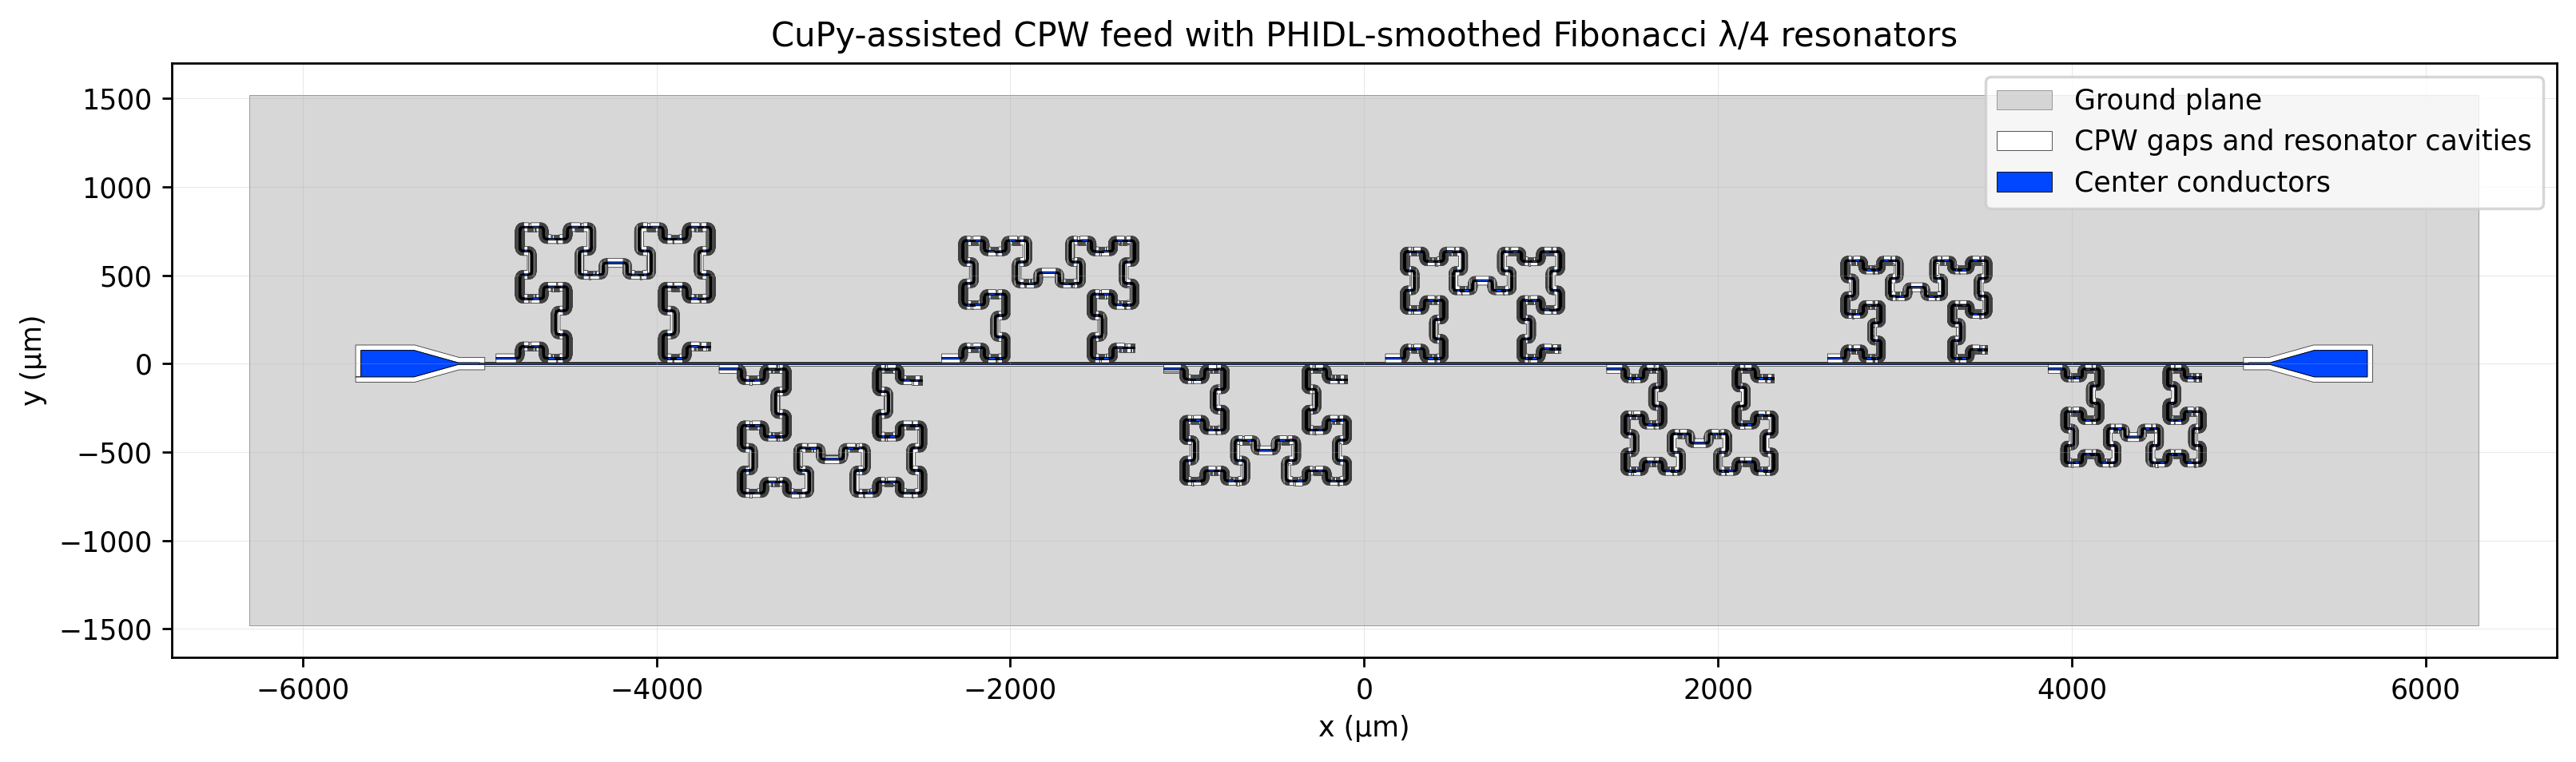

Finished Matplotlib preview in 74.252 s


In [2]:
#@title CuPy-accelerated CPW feed with PHIDL-smoothed Fibonacci resonators
"""Generate a CPW feed with Fibonacci-word fractal quarter-wave resonators.

This Colab-ready script uses CuPy on CUDA-capable runtimes for array-heavy
centerline generation, scaling, placement, and bounds calculations. PHIDL and
GDSTK still perform their geometry-kernel work on the CPU, because those
libraries expose CPU geometry kernels. The default fast layered process keeps
runtime low by writing the ground plane, gap layer, and center-conductor layer
as separate fabrication layers. Set BUILD_EXPLICIT_GROUND_CUTOUT to True when a
single carved ground polygon is needed, accepting a slower GDSTK Boolean step.

Generated layout regions:
    1. Ground plane metal.
    2. CPW and resonator gap openings.
    3. CPW feed, launch pads, and resonator center conductors.
"""

import importlib.util
import subprocess
import sys
import time
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Iterable

# =============================================================================
# Installation control knobs
# =============================================================================
INSTALL_MISSING_PACKAGES = True
INSTALL_CUPY = True
PACKAGE_SPECS = (
    "phidl",
    "gdstk",
    "numpy",
    "matplotlib",
)
CUPY_PACKAGE_SPEC = "cupy-cuda12x"

# =============================================================================
# GPU and execution control knobs
# =============================================================================
FORCE_CUPY = True
PRINT_TIMING = True
PRINT_GPU_INFO = True

# This fast mode writes ground, gaps, and conductors as separate layers.
# It avoids the slowest global frame-minus-all-keepouts Boolean.
BUILD_EXPLICIT_GROUND_CUTOUT = False

# Per-feature Boolean rings remain enabled so the gap layer is a real annular
# CPW gap region around each feed, launch, and resonator conductor.
BUILD_EXPLICIT_GAP_RINGS = True

# =============================================================================
# Global layout control knobs
# =============================================================================
OUTPUT_DIR = Path("/content/fibonacci_cpw_feed_outputs")
OAS_PATH = OUTPUT_DIR / "cupy_qmetal_inspired_fibonacci_cpw_feed_resonators.oas"
GDS_PATH = OUTPUT_DIR / "cupy_qmetal_inspired_fibonacci_cpw_feed_resonators.gds"

WRITE_OAS = True
WRITE_GDS = True
TOP_CELL_NAME = "CUPY_QMETAL_FIBONACCI_CPW_FEED"

GDS_UNIT_M = 1.0e-6
GDS_PRECISION_M = 1.0e-9
BOOLEAN_PRECISION_UM = 2.0e-3
MAX_POLYGON_POINTS = 199

GROUND_LAYER = 1
GROUND_DATATYPE = 0
GAP_LAYER = 2
GAP_DATATYPE = 0
CENTER_LAYER = 3
CENTER_DATATYPE = 0
TEXT_LAYER = 10
TEXT_DATATYPE = 0

# =============================================================================
# Electrical and CPW geometry control knobs
# =============================================================================
FIBONACCI_ITERATIONS = 9
RESONATOR_COUNT = 8
FREQUENCY_START_GHZ = 5.0
FREQUENCY_STOP_GHZ = 7.0
REFERENCE_QUARTER_WAVE_LENGTH_UM = 6000.0
REFERENCE_FREQUENCY_GHZ = 5.0

FEED_LENGTH_UM = 10_000.0
FEED_WIDTH_UM = 10.0
FEED_GAP_UM = 6.0

RESONATOR_WIDTH_UM = 10.0
RESONATOR_GROUND_CLEARANCE_UM = 20.0
FEED_TO_RESONATOR_TRACE_GAP_UM = 20.0
FRACTAL_FILLET_FACTOR = 0.20
PATH_TOLERANCE_UM = 0.06

RESONATOR_X_INSET_UM = 700.0
ALTERNATE_RESONATOR_SIDES = True

# =============================================================================
# Qiskit Metal / Quantum Metal 0.7 inspired launch-pad control knobs
# =============================================================================
LAUNCH_LEAD_LENGTH_UM = 120.0
LAUNCH_TAPER_LENGTH_UM = 250.0
LAUNCH_PAD_LENGTH_UM = 300.0
LAUNCH_PAD_HEIGHT_UM = 150.0
LAUNCH_PAD_GAP_UM = 30.0

# =============================================================================
# Chip envelope and labels
# =============================================================================
CHIP_MARGIN_UM = 600.0
MIN_CHIP_HEIGHT_UM = 3000.0
ADD_TEXT_LABELS = True
TEXT_SIZE_UM = 55.0

# =============================================================================
# Preview control knobs
# =============================================================================
MPL_DPI = 250
SHOW_PREVIEW = True
PREVIEW_FIGSIZE = (13.0, 5.2)
PREVIEW_LINEWIDTH = 0.25
SHOW_LEGEND = True
SHOW_GRID = True


def ensure_packages() -> None:
    """Install missing packages with uv pip when requested."""
    if INSTALL_MISSING_PACKAGES is False:
        return

    required_specs = list(PACKAGE_SPECS)
    if INSTALL_CUPY:
        required_specs.append(CUPY_PACKAGE_SPEC)

    module_by_spec = {
        "cupy-cuda12x": "cupy",
        "matplotlib": "matplotlib",
        "numpy": "numpy",
        "gdstk": "gdstk",
        "phidl": "phidl",
    }
    missing_specs = [
        spec
        for spec in required_specs
        if importlib.util.find_spec(module_by_spec.get(spec, spec)) is None
    ]

    if len(missing_specs) == 0:
        return

    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "uv"],
        check=True,
    )
    subprocess.run(
        [
            sys.executable,
            "-m",
            "uv",
            "pip",
            "install",
            "--system",
            "-q",
            *missing_specs,
        ],
        check=True,
    )


ensure_packages()

import gdstk
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import phidl.path as pp
from matplotlib.patches import Polygon as MplPolygon

try:
    import cupy as cp
except Exception:  # pragma: no cover
    cp = None


mpl.rcParams["figure.dpi"] = MPL_DPI
mpl.rcParams["savefig.dpi"] = MPL_DPI


def select_array_backend() -> tuple[Any, bool]:
    """Return CuPy when a CUDA GPU is available and requested."""
    if FORCE_CUPY is False:
        return np, False

    if cp is None:
        return np, False

    try:
        device_count = cp.cuda.runtime.getDeviceCount()
    except Exception:
        return np, False

    if device_count < 1:
        return np, False

    return cp, True


XP, USING_CUPY = select_array_backend()


DIRECTIONS = XP.asarray(
    (
        (1.0, 0.0),
        (0.0, 1.0),
        (-1.0, 0.0),
        (0.0, -1.0),
    ),
    dtype=XP.float64,
)


@dataclass(frozen=True)
class ResonatorSummary:
    """Summary values for one Fibonacci resonator."""

    index: int
    frequency_ghz: float
    target_length_um: float
    smoothed_length_um: float
    estimated_frequency_ghz: float
    step_um: float
    fillet_radius_um: float
    side: str
    x_center_um: float
    trace_gap_to_feed_um: float


@dataclass(frozen=True)
class LayoutSummary:
    """Summary values for the generated chip layout."""

    fibonacci_word_length: int
    feed_length_um: float
    chip_width_um: float
    chip_height_um: float
    resonators: tuple[ResonatorSummary, ...]
    using_cupy: bool
    explicit_ground_cutout: bool


class Timer:
    """Small timing context manager for Colab progress messages."""

    def __init__(self, label: str) -> None:
        self.label = label
        self.start_time = 0.0

    def __enter__(self) -> "Timer":
        self.start_time = time.perf_counter()
        if PRINT_TIMING:
            print(f"Starting {self.label}...")
        return self

    def __exit__(self, exc_type: object, exc: object, tb: object) -> None:
        elapsed = time.perf_counter() - self.start_time
        if PRINT_TIMING:
            print(f"Finished {self.label} in {elapsed:.3f} s")


def synchronize_gpu() -> None:
    """Synchronize the GPU so timing messages reflect completed kernels."""
    if USING_CUPY:
        XP.cuda.Stream.null.synchronize()


def to_numpy(array: Any) -> np.ndarray:
    """Convert NumPy or CuPy arrays to a NumPy array for PHIDL and GDSTK."""
    if USING_CUPY:
        return cp.asnumpy(array)
    return np.asarray(array)


def as_polygon_list(polygons: object) -> list[gdstk.Polygon]:
    """Convert a GDSTK Boolean result into a polygon list."""
    if polygons is None:
        return []
    return list(polygons)


def rect_polygon(
    x0_um: float,
    y0_um: float,
    x1_um: float,
    y1_um: float,
    *,
    layer: int,
    datatype: int,
) -> gdstk.Polygon:
    """Create a rectangle while allowing either x/y corner order."""
    x_low, x_high = sorted((x0_um, x1_um))
    y_low, y_high = sorted((y0_um, y1_um))
    return gdstk.rectangle(
        (x_low, y_low),
        (x_high, y_high),
        layer=layer,
        datatype=datatype,
    )


def fracture_polygons(
    polygons: Iterable[gdstk.Polygon],
) -> list[gdstk.Polygon]:
    """Fracture polygons so vertex counts stay friendly for GDS viewers."""
    fractured: list[gdstk.Polygon] = []
    for polygon in polygons:
        pieces = polygon.fracture(
            max_points=MAX_POLYGON_POINTS,
            precision=BOOLEAN_PRECISION_UM,
        )
        fractured.extend(pieces)
    return fractured


def polygon_bounds_gpu(
    polygons: Iterable[gdstk.Polygon],
) -> tuple[float, float, float, float]:
    """Return xmin, ymin, xmax, ymax using the selected array backend."""
    polygon_list = list(polygons)
    if len(polygon_list) == 0:
        raise ValueError("Cannot compute bounds for an empty polygon list.")

    min_values = []
    max_values = []
    for polygon in polygon_list:
        points = XP.asarray(polygon.points, dtype=XP.float64)
        min_values.append(XP.min(points, axis=0))
        max_values.append(XP.max(points, axis=0))

    mins = XP.stack(min_values, axis=0)
    maxs = XP.stack(max_values, axis=0)
    global_min = XP.min(mins, axis=0)
    global_max = XP.max(maxs, axis=0)
    synchronize_gpu()

    bounds = to_numpy(XP.concatenate((global_min, global_max)))
    return tuple(float(value) for value in bounds)


def get_cell_bounds(cell: gdstk.Cell) -> tuple[float, float, float, float]:
    """Return a cell bounding box as xmin, ymin, xmax, ymax."""
    bounding_box = cell.bounding_box()
    if bounding_box is None:
        raise ValueError("Cannot preview an empty GDSTK cell.")

    bbox_array = np.asarray(bounding_box, dtype=float)
    if bbox_array.shape != (2, 2):
        raise ValueError(
            "Expected two coordinate pairs from GDSTK bounding_box(), "
            f"received shape {bbox_array.shape}."
        )

    (xmin, ymin), (xmax, ymax) = bbox_array
    return float(xmin), float(ymin), float(xmax), float(ymax)


def fibonacci_word(iterations: int) -> str:
    """Return a Fibonacci word with length 89 when iterations equals 9."""
    if iterations < 1:
        raise ValueError("FIBONACCI_ITERATIONS must be at least 1.")

    word_a = "0"
    word_b = "01"
    if iterations == 1:
        return word_a

    for _ in range(iterations - 1):
        word_a, word_b = word_b, word_b + word_a
    return word_b


def build_fibonacci_unit_polyline(iterations: int) -> Any:
    """Build the canonical Fibonacci-word fractal unit-step centerline."""
    word = fibonacci_word(iterations)
    points = XP.zeros((len(word) + 1, 2), dtype=XP.float64)
    direction_index = 0

    for symbol_index, symbol in enumerate(word):
        if symbol == "0":
            if symbol_index % 2 == 0:
                direction_index = (direction_index + 1) % 4
            else:
                direction_index = (direction_index - 1) % 4
        points[symbol_index + 1] = points[symbol_index] + DIRECTIONS[direction_index]

    synchronize_gpu()
    return points


def rotate_left_90(points: Any) -> Any:
    """Rotate points 90 degrees counterclockwise about the origin."""
    return XP.stack((-points[:, 1], points[:, 0]), axis=1)


def center_points_x(points: Any, x_center_um: float) -> Any:
    """Translate a point cloud so its x-bounding-box center is requested."""
    current_center = 0.5 * (XP.min(points[:, 0]) + XP.max(points[:, 0]))
    translated = points.copy()
    translated[:, 0] += x_center_um - current_center
    return translated


def place_resonator_next_to_feed(
    points: Any,
    *,
    upward: bool,
) -> tuple[Any, float]:
    """Place a resonator at a fixed trace-edge gap from the feed conductor."""
    translated = points.copy()
    feed_half_width = 0.5 * FEED_WIDTH_UM
    resonator_half_width = 0.5 * RESONATOR_WIDTH_UM

    if upward:
        target_centerline_min_y = (
            feed_half_width
            + FEED_TO_RESONATOR_TRACE_GAP_UM
            + resonator_half_width
        )
        y_shift = target_centerline_min_y - XP.min(translated[:, 1])
        translated[:, 1] += y_shift
        trace_gap = (
            XP.min(translated[:, 1])
            - resonator_half_width
            - feed_half_width
        )
    else:
        target_centerline_max_y = -(
            feed_half_width
            + FEED_TO_RESONATOR_TRACE_GAP_UM
            + resonator_half_width
        )
        y_shift = target_centerline_max_y - XP.max(translated[:, 1])
        translated[:, 1] += y_shift
        trace_gap = (
            -feed_half_width
            - (XP.max(translated[:, 1]) + resonator_half_width)
        )

    synchronize_gpu()
    return translated, float(to_numpy(XP.asarray(trace_gap)))


def smooth_centerline(points: np.ndarray, bend_radius_um: float) -> np.ndarray:
    """Smooth an orthogonal centerline with PHIDL Euler bends."""
    if bend_radius_um <= 0.0:
        return points

    try:
        smoothed_path = pp.smooth(
            points=points,
            radius=bend_radius_um,
            corner_fun=pp.euler,
        )
        return np.asarray(smoothed_path.points, dtype=float)
    except Exception as exc:
        print("PHIDL smoothing fallback activated.")
        print(f"Reason: {exc}")
        return points


def path_length_um(points: np.ndarray) -> float:
    """Compute polyline length in micrometers."""
    point_array = XP.asarray(points, dtype=XP.float64)
    deltas = XP.diff(point_array, axis=0)
    lengths = XP.sqrt(XP.sum(deltas * deltas, axis=1))
    total_length = XP.sum(lengths)
    synchronize_gpu()
    return float(to_numpy(XP.asarray(total_length)))


def make_flexpath_polygons(
    points: np.ndarray,
    width_um: float,
    *,
    layer: int,
    datatype: int,
) -> list[gdstk.Polygon]:
    """Create GDSTK polygons from a centerline."""
    flexpath = gdstk.FlexPath(
        points,
        width_um,
        ends="flush",
        joins="round",
        tolerance=PATH_TOLERANCE_UM,
        layer=layer,
        datatype=datatype,
    )
    return list(flexpath.to_polygons())


def make_cpw_gap_ring(
    center_polygons: list[gdstk.Polygon],
    outer_polygons: list[gdstk.Polygon],
) -> list[gdstk.Polygon]:
    """Build a gap ring as outer conductor keepout minus center metal."""
    if BUILD_EXPLICIT_GAP_RINGS is False:
        return fracture_polygons(outer_polygons)

    gap_polygons = as_polygon_list(
        gdstk.boolean(
            outer_polygons,
            center_polygons,
            "not",
            precision=BOOLEAN_PRECISION_UM,
            layer=GAP_LAYER,
            datatype=GAP_DATATYPE,
        )
    )
    return fracture_polygons(gap_polygons)


def offset_polygons(
    polygons: Iterable[gdstk.Polygon],
    distance_um: float,
    *,
    join: str,
    layer: int,
    datatype: int,
) -> list[gdstk.Polygon]:
    """Offset polygons with a consistent GDSTK precision setting."""
    polygon_list = list(polygons)
    if len(polygon_list) == 0:
        return []

    return as_polygon_list(
        gdstk.offset(
            polygon_list,
            distance_um,
            join=join,
            tolerance=PATH_TOLERANCE_UM,
            precision=BOOLEAN_PRECISION_UM,
            layer=layer,
            datatype=datatype,
        )
    )


def build_feed_line() -> tuple[gdstk.Polygon, gdstk.Polygon]:
    """Build the straight CPW feed center conductor and its keepout."""
    center = rect_polygon(
        -0.5 * FEED_LENGTH_UM,
        -0.5 * FEED_WIDTH_UM,
        0.5 * FEED_LENGTH_UM,
        0.5 * FEED_WIDTH_UM,
        layer=CENTER_LAYER,
        datatype=CENTER_DATATYPE,
    )
    outer = rect_polygon(
        -0.5 * FEED_LENGTH_UM,
        -0.5 * (FEED_WIDTH_UM + 2.0 * FEED_GAP_UM),
        0.5 * FEED_LENGTH_UM,
        0.5 * (FEED_WIDTH_UM + 2.0 * FEED_GAP_UM),
        layer=GAP_LAYER,
        datatype=GAP_DATATYPE,
    )
    return center, outer


def build_qmetal_style_launch_pad(
    root_x_um: float,
    direction: int,
) -> gdstk.Polygon:
    """Build a Qiskit Metal / Quantum Metal style wirebond launch pad."""
    if direction not in (-1, 1):
        raise ValueError("direction must be -1 for left or +1 for right.")

    half_feed = 0.5 * FEED_WIDTH_UM
    half_pad = 0.5 * LAUNCH_PAD_HEIGHT_UM

    x_root = root_x_um
    x_lead = x_root + direction * LAUNCH_LEAD_LENGTH_UM
    x_taper = x_lead + direction * LAUNCH_TAPER_LENGTH_UM
    x_pad_end = x_taper + direction * LAUNCH_PAD_LENGTH_UM

    points = [
        (x_root, half_feed),
        (x_lead, half_feed),
        (x_taper, half_pad),
        (x_pad_end, half_pad),
        (x_pad_end, -half_pad),
        (x_taper, -half_pad),
        (x_lead, -half_feed),
        (x_root, -half_feed),
    ]

    return gdstk.Polygon(
        points,
        layer=CENTER_LAYER,
        datatype=CENTER_DATATYPE,
    )


def quarter_wave_lengths_um() -> tuple[Any, Any]:
    """Return target frequencies and quarter-wave lengths."""
    frequencies_ghz = XP.linspace(
        FREQUENCY_START_GHZ,
        FREQUENCY_STOP_GHZ,
        RESONATOR_COUNT,
        dtype=XP.float64,
    )
    lengths_um = (
        REFERENCE_QUARTER_WAVE_LENGTH_UM
        * REFERENCE_FREQUENCY_GHZ
        / frequencies_ghz
    )
    synchronize_gpu()
    return frequencies_ghz, lengths_um


def estimate_frequency_ghz(target_length_um: float) -> float:
    """Estimate frequency from the same length scaling used for targets."""
    return (
        REFERENCE_FREQUENCY_GHZ
        * REFERENCE_QUARTER_WAVE_LENGTH_UM
        / target_length_um
    )


def build_one_resonator(
    *,
    unit_polyline: Any,
    x_center_um: float,
    target_length_um: float,
    frequency_ghz: float,
    index: int,
    upward: bool,
) -> tuple[list[gdstk.Polygon], list[gdstk.Polygon], list[gdstk.Polygon], ResonatorSummary]:
    """Build one rotated Fibonacci-word resonator."""
    number_of_moves = unit_polyline.shape[0] - 1
    step_um = target_length_um / float(number_of_moves)
    fillet_radius_um = step_um * FRACTAL_FILLET_FACTOR

    gpu_points = rotate_left_90(unit_polyline * step_um)
    if upward is False:
        gpu_points = gpu_points.copy()
        gpu_points[:, 1] *= -1.0

    gpu_points = center_points_x(gpu_points, x_center_um)
    gpu_points, trace_gap_um = place_resonator_next_to_feed(
        gpu_points,
        upward=upward,
    )
    raw_points = to_numpy(gpu_points)
    smoothed_points = smooth_centerline(raw_points, fillet_radius_um)

    center_polygons = make_flexpath_polygons(
        smoothed_points,
        RESONATOR_WIDTH_UM,
        layer=CENTER_LAYER,
        datatype=CENTER_DATATYPE,
    )
    outer_polygons = make_flexpath_polygons(
        smoothed_points,
        RESONATOR_WIDTH_UM + 2.0 * RESONATOR_GROUND_CLEARANCE_UM,
        layer=GAP_LAYER,
        datatype=GAP_DATATYPE,
    )
    gap_polygons = make_cpw_gap_ring(center_polygons, outer_polygons)

    smoothed_length_um = path_length_um(smoothed_points)
    estimated_frequency = estimate_frequency_ghz(smoothed_length_um)

    summary = ResonatorSummary(
        index=index,
        frequency_ghz=float(frequency_ghz),
        target_length_um=float(target_length_um),
        smoothed_length_um=float(smoothed_length_um),
        estimated_frequency_ghz=float(estimated_frequency),
        step_um=float(step_um),
        fillet_radius_um=float(fillet_radius_um),
        side="up" if upward else "down",
        x_center_um=float(x_center_um),
        trace_gap_to_feed_um=float(trace_gap_um),
    )
    return center_polygons, outer_polygons, gap_polygons, summary


def build_chip_frame(
    keepout_polygons: Iterable[gdstk.Polygon],
) -> tuple[gdstk.Polygon, float, float]:
    """Build a rectangular chip frame around all keepout polygons."""
    xmin, ymin, xmax, ymax = polygon_bounds_gpu(keepout_polygons)

    chip_width_um = (xmax - xmin) + 2.0 * CHIP_MARGIN_UM
    chip_height_um = max(
        MIN_CHIP_HEIGHT_UM,
        (ymax - ymin) + 2.0 * CHIP_MARGIN_UM,
    )

    center_x = 0.5 * (xmin + xmax)
    center_y = 0.5 * (ymin + ymax)

    frame = rect_polygon(
        center_x - 0.5 * chip_width_um,
        center_y - 0.5 * chip_height_um,
        center_x + 0.5 * chip_width_um,
        center_y + 0.5 * chip_height_um,
        layer=GROUND_LAYER,
        datatype=GROUND_DATATYPE,
    )
    return frame, float(chip_width_um), float(chip_height_um)


def build_ground_polygons(
    frame: gdstk.Polygon,
    keepout_polygons: list[gdstk.Polygon],
) -> list[gdstk.Polygon]:
    """Build either a fast solid ground or an explicitly carved ground."""
    if BUILD_EXPLICIT_GROUND_CUTOUT is False:
        return [frame]

    ground_polygons = as_polygon_list(
        gdstk.boolean(
            [frame],
            keepout_polygons,
            "not",
            precision=BOOLEAN_PRECISION_UM,
            layer=GROUND_LAYER,
            datatype=GROUND_DATATYPE,
        )
    )
    return fracture_polygons(ground_polygons)


def add_labels(cell: gdstk.Cell, summary: LayoutSummary) -> None:
    """Add compact metadata labels to the layout."""
    if ADD_TEXT_LABELS is False:
        return

    mode = "explicit ground" if BUILD_EXPLICIT_GROUND_CUTOUT else "layered gaps"
    label_text = (
        f"8 Fibonacci CPW resonators, n={FIBONACCI_ITERATIONS}, "
        f"feed={FEED_LENGTH_UM / 1000.0:.1f} mm, "
        f"CuPy={summary.using_cupy}, {mode}"
    )
    x0 = -0.5 * summary.chip_width_um + 120.0
    y0 = -0.5 * summary.chip_height_um + 120.0

    text_polygons = gdstk.text(
        label_text,
        TEXT_SIZE_UM,
        (x0, y0),
        layer=TEXT_LAYER,
        datatype=TEXT_DATATYPE,
    )
    cell.add(*text_polygons)


def build_full_chip() -> tuple[gdstk.Library, LayoutSummary]:
    """Build the full chip and return the GDSTK library plus summary."""
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    with Timer("CuPy/NumPy centerline setup"):
        unit_polyline = build_fibonacci_unit_polyline(FIBONACCI_ITERATIONS)
        frequencies_ghz, target_lengths_um = quarter_wave_lengths_um()
        x_positions = XP.linspace(
            -0.5 * FEED_LENGTH_UM + RESONATOR_X_INSET_UM,
            0.5 * FEED_LENGTH_UM - RESONATOR_X_INSET_UM,
            RESONATOR_COUNT,
            dtype=XP.float64,
        )
        freq_np = to_numpy(frequencies_ghz)
        length_np = to_numpy(target_lengths_um)
        x_np = to_numpy(x_positions)

    with Timer("feed and launch geometry"):
        feed_center, feed_outer = build_feed_line()
        left_launch = build_qmetal_style_launch_pad(
            -0.5 * FEED_LENGTH_UM,
            direction=-1,
        )
        right_launch = build_qmetal_style_launch_pad(
            0.5 * FEED_LENGTH_UM,
            direction=1,
        )
        launch_outers = []
        launch_outers.extend(
            offset_polygons(
                [left_launch],
                LAUNCH_PAD_GAP_UM,
                join="miter",
                layer=GAP_LAYER,
                datatype=GAP_DATATYPE,
            )
        )
        launch_outers.extend(
            offset_polygons(
                [right_launch],
                LAUNCH_PAD_GAP_UM,
                join="miter",
                layer=GAP_LAYER,
                datatype=GAP_DATATYPE,
            )
        )

        center_conductors: list[gdstk.Polygon] = [
            feed_center,
            left_launch,
            right_launch,
        ]
        keepout_polygons: list[gdstk.Polygon] = [feed_outer, *launch_outers]
        gap_polygons: list[gdstk.Polygon] = []
        gap_polygons.extend(make_cpw_gap_ring([feed_center], [feed_outer]))
        gap_polygons.extend(
            make_cpw_gap_ring([left_launch, right_launch], launch_outers)
        )

    resonator_summaries: list[ResonatorSummary] = []
    with Timer("resonator PHIDL smoothing and local GDSTK gap rings"):
        for idx, (x_center, frequency, length_um) in enumerate(
            zip(x_np, freq_np, length_np),
            start=1,
        ):
            upward = True
            if ALTERNATE_RESONATOR_SIDES:
                upward = idx % 2 == 1

            center_polys, outer_polys, gap_polys, res_summary = build_one_resonator(
                unit_polyline=unit_polyline,
                x_center_um=float(x_center),
                target_length_um=float(length_um),
                frequency_ghz=float(frequency),
                index=idx,
                upward=upward,
            )
            center_conductors.extend(center_polys)
            keepout_polygons.extend(outer_polys)
            gap_polygons.extend(gap_polys)
            resonator_summaries.append(res_summary)

    with Timer("chip frame and optional ground cutout"):
        chip_frame, chip_width_um, chip_height_um = build_chip_frame(
            keepout_polygons
        )
        ground_polygons = build_ground_polygons(chip_frame, keepout_polygons)

    with Timer("fracture and cell assembly"):
        center_conductors = fracture_polygons(center_conductors)
        gap_polygons = fracture_polygons(gap_polygons)
        ground_polygons = fracture_polygons(ground_polygons)

        library = gdstk.Library(unit=GDS_UNIT_M, precision=GDS_PRECISION_M)
        cell = library.new_cell(TOP_CELL_NAME)
        cell.add(*ground_polygons)
        cell.add(*gap_polygons)
        cell.add(*center_conductors)

        summary = LayoutSummary(
            fibonacci_word_length=len(fibonacci_word(FIBONACCI_ITERATIONS)),
            feed_length_um=FEED_LENGTH_UM,
            chip_width_um=chip_width_um,
            chip_height_um=chip_height_um,
            resonators=tuple(resonator_summaries),
            using_cupy=USING_CUPY,
            explicit_ground_cutout=BUILD_EXPLICIT_GROUND_CUTOUT,
        )
        add_labels(cell, summary)

    return library, summary


def plot_polygons(
    ax: plt.Axes,
    polygons: Iterable[gdstk.Polygon],
    *,
    facecolor: str,
    edgecolor: str,
    alpha: float,
    label: str,
) -> None:
    """Render GDSTK polygons on a Matplotlib axis."""
    first_entry = True
    for polygon in polygons:
        patch = MplPolygon(
            polygon.points,
            closed=True,
            facecolor=facecolor,
            edgecolor=edgecolor,
            linewidth=PREVIEW_LINEWIDTH,
            alpha=alpha,
            label=label if first_entry else None,
        )
        ax.add_patch(patch)
        first_entry = False


def preview_cell(library: gdstk.Library) -> None:
    """Render a layout preview directly in Colab."""
    cell = library.top_level()[0]
    polygons_by_layer = {
        GROUND_LAYER: [],
        GAP_LAYER: [],
        CENTER_LAYER: [],
    }

    for polygon in cell.polygons:
        if polygon.layer in polygons_by_layer:
            polygons_by_layer[polygon.layer].append(polygon)

    fig, ax = plt.subplots(figsize=PREVIEW_FIGSIZE)
    plot_polygons(
        ax,
        polygons_by_layer[GROUND_LAYER],
        facecolor="#D0D0D0",
        edgecolor="#808080",
        alpha=0.85,
        label="Ground plane",
    )
    plot_polygons(
        ax,
        polygons_by_layer[GAP_LAYER],
        facecolor="#FFFFFF",
        edgecolor="#404040",
        alpha=1.0,
        label="CPW gaps and resonator cavities",
    )
    plot_polygons(
        ax,
        polygons_by_layer[CENTER_LAYER],
        facecolor="#0047FF",
        edgecolor="#000000",
        alpha=1.0,
        label="Center conductors",
    )

    xmin, ymin, xmax, ymax = get_cell_bounds(cell)
    pad_x = max(1.0, 0.035 * (xmax - xmin))
    pad_y = max(1.0, 0.06 * (ymax - ymin))

    ax.set_xlim(xmin - pad_x, xmax + pad_x)
    ax.set_ylim(ymin - pad_y, ymax + pad_y)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("x (µm)")
    ax.set_ylabel("y (µm)")
    ax.set_title(
        "CuPy-assisted CPW feed with PHIDL-smoothed Fibonacci λ/4 resonators"
    )
    if SHOW_LEGEND:
        ax.legend(loc="upper right")
    if SHOW_GRID:
        ax.grid(True, linewidth=0.25, alpha=0.35)
    plt.tight_layout()
    plt.show()


def print_gpu_info() -> None:
    """Print the selected numerical backend and GPU details."""
    print(f"Array backend: {'CuPy' if USING_CUPY else 'NumPy'}")
    if USING_CUPY and PRINT_GPU_INFO:
        device = cp.cuda.Device()
        props = cp.cuda.runtime.getDeviceProperties(device.id)
        name = props["name"].decode("utf-8")
        free_bytes, total_bytes = cp.cuda.runtime.memGetInfo()
        print(f"CUDA device: {name}")
        print(f"GPU memory free/total: {free_bytes / 2**30:.2f} / {total_bytes / 2**30:.2f} GiB")
    elif FORCE_CUPY:
        print("CuPy was requested, although no active CUDA backend was selected.")


def print_summary(summary: LayoutSummary) -> None:
    """Print a compact design summary."""
    print("Generated CuPy-assisted QMetal-inspired Fibonacci CPW feed layout")
    print(f"Top cell: {TOP_CELL_NAME}")
    print(f"CuPy active: {summary.using_cupy}")
    print(f"Explicit carved ground: {summary.explicit_ground_cutout}")
    print(f"Fibonacci substitutions: {FIBONACCI_ITERATIONS}")
    print(f"Fibonacci word length: {summary.fibonacci_word_length} segments")
    print(f"Feed length: {summary.feed_length_um / 1000.0:.3f} mm")
    print(
        "Chip envelope: "
        f"{summary.chip_width_um / 1000.0:.3f} mm × "
        f"{summary.chip_height_um / 1000.0:.3f} mm"
    )
    print(f"Ground layer: {GROUND_LAYER}")
    print(f"Gap layer: {GAP_LAYER}")
    print(f"Center conductor layer: {CENTER_LAYER}")
    print("")
    print("Resonator table")
    print(
        "idx  side  target_GHz  estimated_GHz  "
        "L_target_mm  L_smooth_mm  step_um  fillet_um  gap_um"
    )
    for item in summary.resonators:
        print(
            f"{item.index:>3d}  "
            f"{item.side:>4s}  "
            f"{item.frequency_ghz:>10.4f}  "
            f"{item.estimated_frequency_ghz:>13.4f}  "
            f"{item.target_length_um / 1000.0:>11.4f}  "
            f"{item.smoothed_length_um / 1000.0:>11.4f}  "
            f"{item.step_um:>7.3f}  "
            f"{item.fillet_radius_um:>9.3f}  "
            f"{item.trace_gap_to_feed_um:>6.3f}"
        )

    if WRITE_OAS:
        print(f"OASIS path: {OAS_PATH}")
    if WRITE_GDS:
        print(f"GDS path: {GDS_PATH}")


def main() -> LayoutSummary:
    """Generate, export, preview, and summarize the layout."""
    print_gpu_info()

    with Timer("full layout build"):
        library, summary = build_full_chip()

    with Timer("layout export"):
        if WRITE_OAS:
            library.write_oas(str(OAS_PATH))
        if WRITE_GDS:
            library.write_gds(str(GDS_PATH))

    print_summary(summary)

    if SHOW_PREVIEW:
        with Timer("Matplotlib preview"):
            preview_cell(library)

    return summary


if __name__ == "__main__":
    results = main()